# Superstore Sales Performance Analysis
This analysis follows a structured data analysis approach including data cleaning, exploration, and business interpretation.

## Project Objective
To evaluate overall sales performance and identify business insights across product categories, yearly trends, and regional distribution.

## Dataset Overview
This dataset is the Superstore Sales Dataset shared on Kaggle by Rohit Sahoo.
It is a commonly used retail dataset for analytical practice.

The dataset contains 9800 transactions and 18 columns, including order date, customer information, product category, region, and sales amount.

Source Platform: Kaggle

Kaggle Contributor: Rohit Sahoo

## Analytical Focus
The analysis focuses on:
- Yearly Sales Trend
- Sales by Category
- Sales by Region

## Tools Used
- Pandas for data processing
- Numpy for numerical operations
- Matplotlib for data visualization

## Data Cleaning
Before conducting the analysis, the dataset was reviewed for data quality and structure.

- Verified dataset size (9800 rows, 18 columns)
- Converted "Order Date and "Ship Date" to datetime format
- Checked for missing values
- Removed 11 rows with missing Postal Code (low impact on overall analysis)

The dataset was confirmed to be clean and ready for exploratory analysis.

## Sales by Category
To identify the primary revenue driver, sales performance was analyzed across product categories.

This section evaluates total sales contribution by each category to understand business dependancy and product strength.

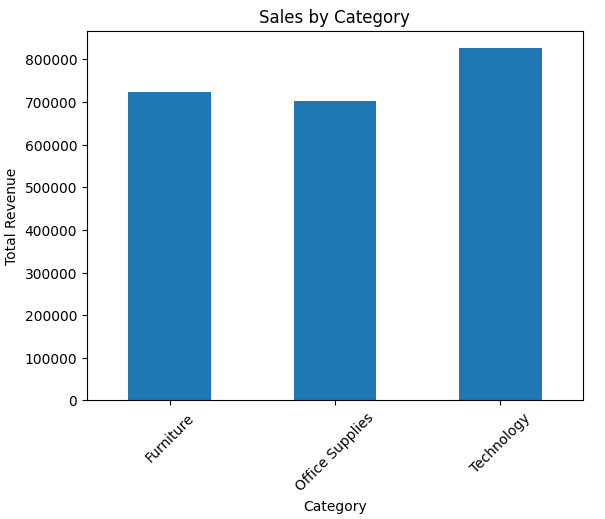

Technology generated the highest revenue among all categories, followed by Furniture and Office Supplies.
This indicates that Technology is the primary revenue driver for the business.

## Yearly Sales Trend
Year-overyear sales performance was analyzed to evaluate business growth and recovery patterns.

This analysis helps determine whether the company is experiencing expansion, decline, or stable growth.

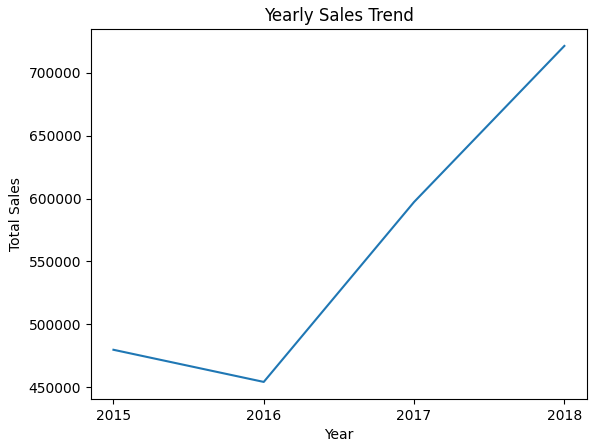

The company experienced a slight sales decline in 2016, followed by a strong recovery from 2016 to 2018.
Sales peaked in 2018, indicating sustained growth momentum after the temporary downturn.

Then, the graph below shows the percentage of growth rate with each year.
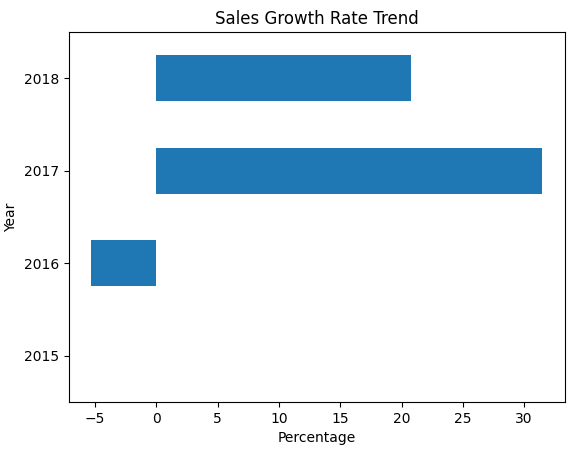

Sales declined by 5.32% in 2016.
The highest growth rate occurred between 2016 and 2017 at 31.46%, demonstrating strong recovery momentum.
Growth remained positive in 2018 at 20.76%, indicating continued business expansion.

## Sales by Region
Regional sales distribution was analyzed to identify top-performing and underperforming markets.

Understanding regional gaps supports strategic market expansion decisions.

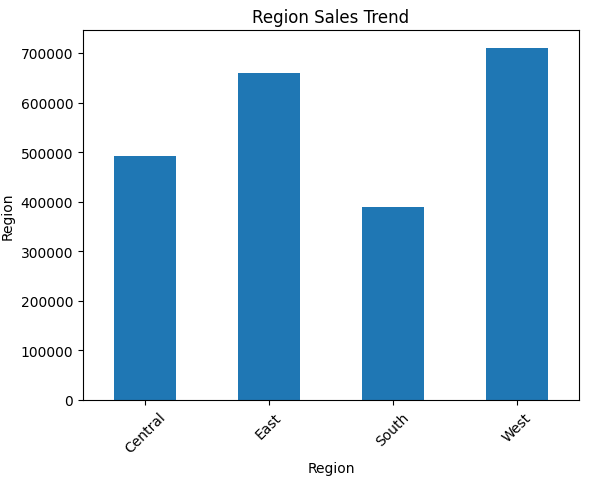

The West region generated the highest total revenue (approximately 710K), while the South region recorded the lowest (approximately 389K).
The revenue gap of over 321K highlights a significant regional imbalance, suggesting potential growth opportunities in underperforming markets.

## Key Findings

* Technology generated the highest total revenue among all product categories.
* Sales experienced a decline in 2016 but showed strong recovery from 2016 to 2018.
* The West region recorded the highest sales performance.
* A significant revenue gap exists between the West and South regions.

## Recommendations

* Increase marketing and product investment in the Technology category, as it generates the highest revenue.
* Investigate the South region’s lower performance and explore opportunities to improve market penetration.
* Continue supporting growth strategies that contributed to the sales recovery after 2016.

## Conclusion
The analysis reveals that Technology is the strongest revenue contributor.  
After a decline in 2016, the business experienced strong recovery and growth through 2018.  
The West region significantly outperforms the South region, indicating potential market imbalance.

These findings provide insights for future strategic planning and resource allocation.

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
df = pd.read_csv('/kaggle/input/datasets/rohitsahoo/sales-forecasting/train.csv')
df.head(10)

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
df.describe()

In [ ]:
print(df['Category'].nunique()) #total number of the object
print(df['Category'].unique()) #name of each object

In [ ]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'],format = "%d/%m/%Y")
df['Order Date'] = pd.to_datetime(df['Order Date'],format = "%d/%m/%Y")

In [ ]:
df.columns

In [ ]:
df = df.dropna(subset=['Postal Code']) # delete the subset to prevent any effect and also cannot replace to any value otherwise the realistic and intergrity is not correct

In [ ]:
dfsum = df['Sales'].sum()
dfmean = round(df['Sales'].mean(),2)
print(dfsum)
print(dfmean)

In [ ]:
s=df.groupby('Category')['Sales'].sum()
r=round(df.groupby('Category')['Sales'].sum(),2)

print(s)
print("\nRound up",r)

print("\nSort", r.sort_values(ascending=False))

In [ ]:
import matplotlib.pyplot as plt

s.plot(kind='bar')
plt.title("Sales by Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

In [ ]:
sumcategory = df.groupby('Category')['Sales'].sum()

print("Highest is=",sumcategory.idxmax(),round(sumcategory.max(),2))
print("Lowest is=", sumcategory.idxmin(),round(sumcategory.min(),2))

#To look the max and min sales with each category

In [ ]:
#Begin to make a time trend - generate a sales report within each year
df['Year'] = df['Order Date'].dt.year
yearly_sales = df.groupby('Year')['Sales'].sum()
yearly_sales.index = yearly_sales.index.astype(int)
round(yearly_sales,2)

In [ ]:
#import matplotlib to show the graph of the yearly sales trend
import matplotlib.pyplot as plt

yearly_sales.plot(kind='line')
plt.title("Yearly Sales Trend")
plt.ylabel("Total Sales")
plt.xticks(yearly_sales.index)
plt.show()

In [ ]:
#To determine the sales growth percentage in each year
growth_rate = yearly_sales.pct_change()*100
print(growth_rate)
print(round(growth_rate,2))


In [ ]:
import matplotlib.pyplot as plt

growth_rate.plot(kind='barh')
plt.title("Sales Growth Rate Trend")
plt.ylabel("Year")
plt.xlabel("Percentage")
plt.show()

In [ ]:
region_sales = df.groupby('Region')['Sales'].sum()
print(region_sales)
print("\nAscending : ", region_sales.sort_values(ascending=False))
print("\nRevenue Gap : ", round((region_sales.max()-region_sales.min()),2))
print("\nBest Region :", region_sales.idxmax(), region_sales.max())
print("\nWorst Region :", region_sales.idxmin(), region_sales.min())

In [ ]:
import matplotlib.pyplot as plt

region_sales.plot(kind='bar')
plt.title("Region Sales Trend")
plt.ylabel("Region")
plt.xticks(rotation=45)
plt.show()